In [ ]:
import json
import pathlib
import warnings
from collections import defaultdict, Counter

import numpy as np
import scipy.sparse as sp
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")

ROOT       = pathlib.Path("..").resolve()
DATA_DIR   = ROOT / "data"
ARTIFACTS  = ROOT / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)

BUNDLE_PATH = DATA_DIR / "enterprise-attack.json"

USE_ROOT_TECHNIQUE_ONLY = True

print(f"Bundle path : {BUNDLE_PATH}")
print(f"Artifacts   : {ARTIFACTS}")
print(f"Root techniques only: {USE_ROOT_TECHNIQUE_ONLY}")


Bundle path : C:\Users\BIT\OneDrive - Birla Institute of Technology\Pictures\apt\data\enterprise-attack.json
Artifacts   : C:\Users\BIT\OneDrive - Birla Institute of Technology\Pictures\apt\artifacts
Root techniques only: True


In [ ]:
with open(BUNDLE_PATH, encoding="utf-8") as f:
    bundle = json.load(f)

objects = bundle["objects"]

by_type = Counter(o["type"] for o in objects)
print("Object counts by type:")
for t, c in sorted(by_type.items(), key=lambda x: -x[1]):
    print(f"  {t:<35} {c:>5}")

groups     = {o["id"]: o for o in objects if o["type"] == "intrusion-set"}
techniques = {o["id"]: o for o in objects if o["type"] == "attack-pattern"}
rels       = [o for o in objects if o["type"] == "relationship"
              and o.get("relationship_type") == "uses"]

print(f"\nGroups (intrusion-set) : {len(groups)}")
print(f"Techniques (attack-pattern): {len(techniques)}")
print(f"'uses' relationships       : {len(rels)}")



Object counts by type:
  relationship                        21025
  x-mitre-analytic                     1758
  attack-pattern                        858
  malware                               729
  x-mitre-detection-strategy            699
  course-of-action                      268
  intrusion-set                         189
  x-mitre-data-component                109
  tool                                   95
  campaign                               56
  x-mitre-data-source                    38
  x-mitre-tactic                         15
  x-mitre-matrix                          1
  identity                                1
  marking-definition                      1

Groups (intrusion-set) : 189
Techniques (attack-pattern): 858
'uses' relationships       : 18220


In [9]:
def is_deprecated(obj):
    return obj.get("x_mitre_deprecated", False) or obj.get("revoked", False)

groups_clean     = {k: v for k, v in groups.items()     if not is_deprecated(v)}
techniques_clean = {k: v for k, v in techniques.items() if not is_deprecated(v)}

print(f"Groups     after deprecation filter: {len(groups_clean)}")
print(f"Techniques after deprecation filter: {len(techniques_clean)}")


Groups     after deprecation filter: 174
Techniques after deprecation filter: 697


In [12]:
def get_technique_id(tech_obj):
    """Extract external technique ID (e.g. T1059). Strips sub-technique suffix if configured."""
    for ref in tech_obj.get("external_references", []):
        if ref.get("source_name") == "mitre-attack":
            tid = ref["external_id"]
            if USE_ROOT_TECHNIQUE_ONLY and "." in tid:
                tid = tid.split(".")[0]   
            return tid
    return None

tech_id_map = {}
for stix_id, obj in techniques_clean.items():
    tid = get_technique_id(obj)
    if tid:
        tech_id_map[stix_id] = tid

group_techniques = defaultdict(set)
skipped = 0
for r in rels:
    src = r.get("source_ref", "")
    tgt = r.get("target_ref", "")
    if src in groups_clean and tgt in tech_id_map:
        group_techniques[src].add(tech_id_map[tgt])
    else:
        skipped += 1

print(f"Groups with ≥1 technique : {len(group_techniques)}")
print(f"Skipped relationships    : {skipped}  (deprecated src/tgt or non-group→technique)")


Groups with ≥1 technique : 170
Skipped relationships    : 13674  (deprecated src/tgt or non-group→technique)


In [13]:
counts = {groups_clean[gid]["name"]: len(techs)
          for gid, techs in group_techniques.items()}
count_vals = sorted(counts.values())

print(f"Min techniques per group  : {min(count_vals)}")
print(f"Max techniques per group  : {max(count_vals)}")
print(f"Mean techniques per group : {np.mean(count_vals):.1f}")
print(f"Median                    : {np.median(count_vals):.1f}")
print(f"Groups with < 3 techniques: {sum(1 for c in count_vals if c < 3)}")
print(f"Groups with < 5 techniques: {sum(1 for c in count_vals if c < 5)}")

# Save EDA artifact
with open(ARTIFACTS / "group_tech_counts.json", "w") as f:
    json.dump(counts, f, indent=2)
print("\nSaved → artifacts/group_tech_counts.json")


Min techniques per group  : 1
Max techniques per group  : 87
Mean techniques per group : 21.5
Median                    : 16.0
Groups with < 3 techniques: 11
Groups with < 5 techniques: 22

Saved → artifacts/group_tech_counts.json


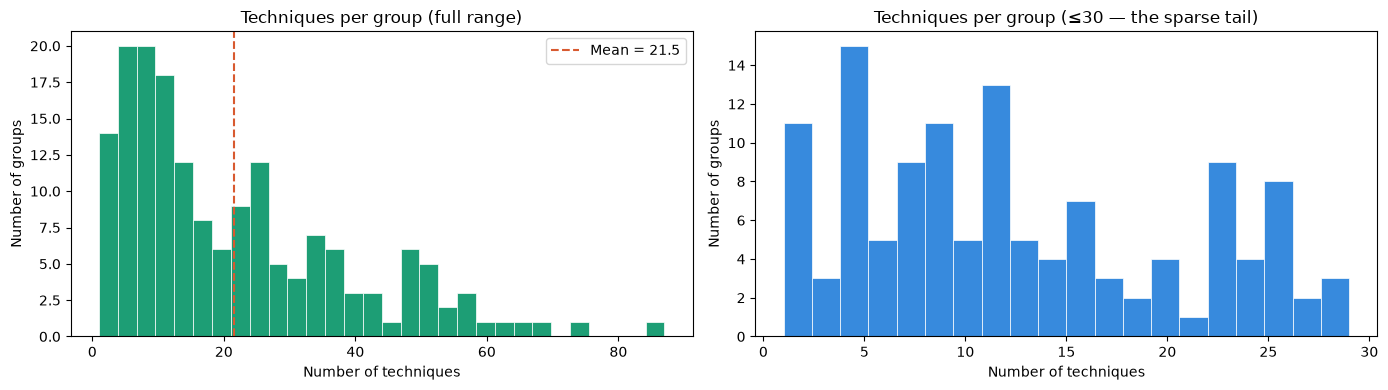

Saved → artifacts/technique_distribution.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(count_vals, bins=30, color="#1D9E75", edgecolor="white", linewidth=0.5)
axes[0].set_title("Techniques per group (full range)", fontsize=12)
axes[0].set_xlabel("Number of techniques")
axes[0].set_ylabel("Number of groups")
axes[0].axvline(np.mean(count_vals), color="#D85A30", linestyle="--", label=f"Mean = {np.mean(count_vals):.1f}")
axes[0].legend()

axes[1].hist([c for c in count_vals if c <= 30], bins=20, color="#378ADD", edgecolor="white", linewidth=0.5)
axes[1].set_title("Techniques per group (≤30 — the sparse tail)", fontsize=12)
axes[1].set_xlabel("Number of techniques")
axes[1].set_ylabel("Number of groups")

plt.tight_layout()
plt.savefig(ARTIFACTS / "technique_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → artifacts/technique_distribution.png")


In [15]:
# Flag thin groups explicitly for the engineering report
THIN_THRESHOLD = 3
thin_groups = {name: cnt for name, cnt in counts.items() if cnt < THIN_THRESHOLD}
print(f"\n⚠  Thin groups (< {THIN_THRESHOLD} techniques) — {len(thin_groups)} total:")
for name, cnt in sorted(thin_groups.items(), key=lambda x: x[1]):
    print(f"   {cnt:>2} technique(s) — {name}")
print("\nThese groups will likely fail classification. Document as known limitation.")



⚠  Thin groups (< 3 techniques) — 11 total:
    1 technique(s) — GCMAN
    1 technique(s) — BlackOasis
    1 technique(s) — APT16
    1 technique(s) — Moafee
    1 technique(s) — Scarlet Mimic
    2 technique(s) — Orangeworm
    2 technique(s) — APT17
    2 technique(s) — SilverTerrier
    2 technique(s) — AppleJeus
    2 technique(s) — PittyTiger
    2 technique(s) — APT30

These groups will likely fail classification. Document as known limitation.


In [16]:
# ── feature vocab: all unique technique IDs across all groups ─
all_technique_ids = sorted({tid for techs in group_techniques.values() for tid in techs})
feature_vocab     = {tid: idx for idx, tid in enumerate(all_technique_ids)}

# ── label encoder: group name → integer class ─────────────────
group_names = sorted(
    groups_clean[gid]["name"]
    for gid in group_techniques
)
label_encoder = LabelEncoder()
label_encoder.fit(group_names)

print(f"Feature dimensions : {len(feature_vocab):>5}  (unique technique IDs after root-only collapse)")
print(f"Classes (groups)   : {len(label_encoder.classes_):>5}")
print(f"\nFirst 10 features  : {all_technique_ids[:10]}")
print(f"First 5 classes    : {list(label_encoder.classes_[:5])}")


Feature dimensions :   201  (unique technique IDs after root-only collapse)
Classes (groups)   :   170

First 10 features  : ['T1001', 'T1003', 'T1005', 'T1006', 'T1007', 'T1008', 'T1010', 'T1012', 'T1014', 'T1016']
First 5 classes    : [np.str_('APT-C-36'), np.str_('APT1'), np.str_('APT12'), np.str_('APT16'), np.str_('APT17')]


In [17]:
n_groups     = len(label_encoder.classes_)
n_techniques = len(feature_vocab)

rows, cols = [], []

for gid, techs in group_techniques.items():
    group_name = groups_clean[gid]["name"]
    class_idx  = label_encoder.transform([group_name])[0]
    for tid in techs:
        if tid in feature_vocab:
            rows.append(class_idx)
            cols.append(feature_vocab[tid])

data = np.ones(len(rows), dtype=np.float32)
X_sparse = sp.csr_matrix((data, (rows, cols)), shape=(n_groups, n_techniques))

print(f"Matrix shape    : {X_sparse.shape}")
print(f"Non-zero entries: {X_sparse.nnz}")
sparsity = 1.0 - X_sparse.nnz / (X_sparse.shape[0] * X_sparse.shape[1])
print(f"Sparsity        : {sparsity:.4%}  (expect > 95%)")


Matrix shape    : (170, 201)
Non-zero entries: 3658
Sparsity        : 89.2947%  (expect > 95%)


In [18]:
# Spot-check: APT28 (well-known group with many techniques)
probe_name = None
for name in label_encoder.classes_:
    if "APT28" in name:
        probe_name = name
        break

if probe_name:
    idx  = label_encoder.transform([probe_name])[0]
    row  = X_sparse[idx]
    tids = [all_technique_ids[i] for i in row.indices]
    print(f"Probe group : {probe_name}")
    print(f"Techniques  : {len(tids)}")
    print(f"Sample IDs  : {tids[:10]}")
else:
    print("APT28 not found under that name — check label_encoder.classes_ manually")

# All rows must have at least 1 technique
row_sums = np.array(X_sparse.sum(axis=1)).flatten()
assert (row_sums > 0).all(), "Some groups have zero techniques — check filtering!"
print(f"\nAll {n_groups} groups have ≥1 technique ✓")
print(f"Row-sum stats → min={row_sums.min():.0f}  mean={row_sums.mean():.1f}  max={row_sums.max():.0f}")


Probe group : APT28
Techniques  : 73
Sample IDs  : ['T1001', 'T1003', 'T1005', 'T1014', 'T1021', 'T1025', 'T1027', 'T1030', 'T1036', 'T1037']

All 170 groups have ≥1 technique ✓
Row-sum stats → min=1  mean=21.5  max=87


In [ ]:
sp.save_npz(ARTIFACTS / "X_sparse.npz", X_sparse)
joblib.dump(label_encoder, ARTIFACTS / "label_encoder.joblib")
joblib.dump(feature_vocab, ARTIFACTS / "feature_vocab.joblib")

print("Saved artifacts:")
for p in sorted(ARTIFACTS.glob("*")):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:<35} {size_kb:>7.1f} KB")
